<a href="https://colab.research.google.com/github/M-marshiro/Fliprobo-Projects/blob/main/Homework5_question2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [20]:
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import time

In [21]:
mnist = fetch_openml('mnist_784', version=1, as_frame=False)

X = mnist.data
y = mnist.target

In [22]:
print("Shape of X:", X.shape)
print("Shape of y:", y.shape)
print("Number of features:", X.shape[1])
print("First 10 target values:", y[:10])

Shape of X: (70000, 784)
Shape of y: (70000,)
Number of features: 784
First 10 target values: ['5' '0' '4' '1' '9' '2' '1' '3' '1' '4']


In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=11,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (56000, 784)
Testing set: (14000, 784)


In [24]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training data shape after scaling:", X_train_scaled.shape)
print("Testing data shape after scaling:", X_test_scaled.shape)

Training data shape after scaling: (56000, 784)
Testing data shape after scaling: (14000, 784)


In [25]:
logisticRegr = LogisticRegression(
    solver='lbfgs',
    max_iter=1000
)

In [26]:
start_time = time.time()

logisticRegr.fit(X_train_scaled, y_train)

end_time = time.time()

time_without_pca = end_time - start_time

print("Training time without PCA:", round(time_without_pca, 2), "seconds")

Training time without PCA: 68.84 seconds


In [27]:
y_pred_without_pca = logisticRegr.predict(X_test_scaled)

accuracy_without_pca = accuracy_score(
    y_test,
    y_pred_without_pca
)

print("Accuracy without PCA:", accuracy_without_pca)
print("Accuracy without PCA:", round(accuracy_without_pca * 100, 2), "%")

Accuracy without PCA: 0.9132857142857143
Accuracy without PCA: 91.33 %


In [28]:
pca = PCA(n_components=0.95)

start_pca = time.time()

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

end_pca = time.time()

pca_time = end_pca - start_pca

In [29]:
print("Original number of features:", X_train_scaled.shape[1])
print("Number of features after PCA:", X_train_pca.shape[1])
print("Explained variance:", pca.explained_variance_ratio_.sum())
print("PCA processing time:", round(pca_time, 2), "seconds")

Original number of features: 784
Number of features after PCA: 331
Explained variance: 0.9502825285063198
PCA processing time: 2.7 seconds


In [30]:
logisticRegr_pca = LogisticRegression(
    solver='lbfgs',
    max_iter=1000
)

In [31]:
start_time = time.time()

logisticRegr_pca.fit(X_train_pca, y_train)

end_time = time.time()

time_with_pca = end_time - start_time

print("Training time with PCA:", round(time_with_pca, 2), "seconds")

Training time with PCA: 46.99 seconds


In [32]:
y_pred_with_pca = logisticRegr_pca.predict(X_test_pca)

accuracy_with_pca = accuracy_score(
    y_test,
    y_pred_with_pca
)

print("Accuracy with PCA:", accuracy_with_pca)
print("Accuracy with PCA:", round(accuracy_with_pca * 100, 2), "%")

Accuracy with PCA: 0.9219285714285714
Accuracy with PCA: 92.19 %


In [33]:
print("----- WITHOUT PCA -----")
print("Number of features:", X_train_scaled.shape[1])
print("Training time:", round(time_without_pca, 2), "seconds")
print("Accuracy:", round(accuracy_without_pca * 100, 2), "%")

print("\n----- WITH PCA -----")
print("Number of features:", X_train_pca.shape[1])
print("Training time:", round(time_with_pca, 2), "seconds")
print("Accuracy:", round(accuracy_with_pca * 100, 2), "%")

print("\n----- DIFFERENCE -----")
print(
    "Time saved:",
    round(time_without_pca - time_with_pca, 2),
    "seconds"
)

print(
    "Accuracy difference:",
    round((accuracy_with_pca - accuracy_without_pca) * 100, 2),
    "percentage points"
)

----- WITHOUT PCA -----
Number of features: 784
Training time: 68.84 seconds
Accuracy: 91.33 %

----- WITH PCA -----
Number of features: 331
Training time: 46.99 seconds
Accuracy: 92.19 %

----- DIFFERENCE -----
Time saved: 21.85 seconds
Accuracy difference: 0.86 percentage points


In [34]:
speedup = time_without_pca / time_with_pca

print("Logistic Regression speedup with PCA:", round(speedup, 2), "times")

Logistic Regression speedup with PCA: 1.46 times


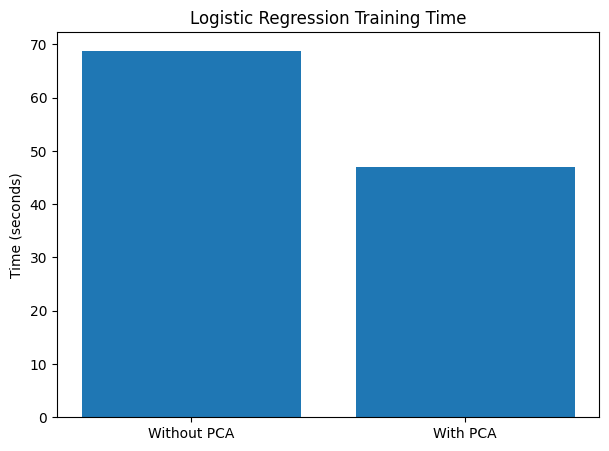

In [35]:
methods = ['Without PCA', 'With PCA']
training_times = [time_without_pca, time_with_pca]

plt.figure(figsize=(7, 5))
plt.bar(methods, training_times)

plt.title('Logistic Regression Training Time')
plt.ylabel('Time (seconds)')

plt.show()

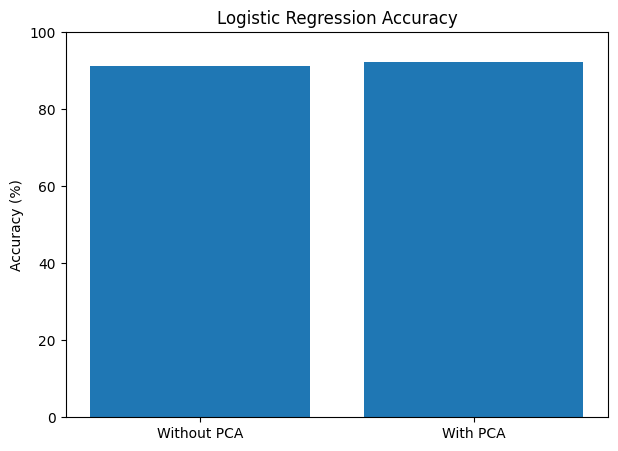

In [36]:
methods = ['Without PCA', 'With PCA']
accuracies = [
    accuracy_without_pca * 100,
    accuracy_with_pca * 100
]

plt.figure(figsize=(7, 5))
plt.bar(methods, accuracies)

plt.title('Logistic Regression Accuracy')
plt.ylabel('Accuracy (%)')
plt.ylim(0, 100)

plt.show()

In [37]:
total_time_with_pca = pca_time + time_with_pca

print("PCA processing time:", round(pca_time, 2), "seconds")
print("Logistic Regression training time with PCA:",
      round(time_with_pca, 2), "seconds")

print("Total PCA + Logistic Regression time:",
      round(total_time_with_pca, 2), "seconds")

print("Logistic Regression training time without PCA:",
      round(time_without_pca, 2), "seconds")

PCA processing time: 2.7 seconds
Logistic Regression training time with PCA: 46.99 seconds
Total PCA + Logistic Regression time: 49.69 seconds
Logistic Regression training time without PCA: 68.84 seconds


In [38]:
## Conclusionn In this project, I used Logistic Regression to classify the MNIST dataset before and after applying PCA. The original dataset had 784 features, and PCA reduced the number of features while keeping 95% of the variance.The results show that Logistic Regression took less training time after PCA dimensionality reduction. The accuracy changed only slightly compared with using all of the original features. This shows that PCA can reduce the complexity of the MNIST dataset and help Logistic Regression train faster while keeping similar classification performance.